In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv(r"C:\Users\ABL\Desktop\kaggle_survey_2017_2021.csv")
df.head()

C:\Users\ABL\AppData\Local\Temp\ipykernel_15348\2439496177.py:1: DtypeWarning: Columns (0,1,8,9,10,11,12,13,14,15,16,17,18,19,20,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,2

,-,Time from Start to Finish (seconds),Q1,Q2,Q3,Q4,Q5,Q6,Q7_Part_1,Q7_Part_2,...,Q38_B_Part_1,Q38_B_Part_2,Q38_B_Part_3,Q38_B_Part_4,Q38_B_Part_5,Q38_B_Part_6,Q38_B_Part_7,Q38_B_Part_9,Q38_B_Part_11,Q38_B_OTHER
0,Year,Duration (in seconds),What is your age (# years)?,What is your gender? - Selected Choice,In which country do you currently reside?,What is the highest level of formal education ...,Select the title most similar to your current ...,For how many years have you been writing code ...,What programming languages do you use on a reg...,What programming languages do you use on a reg...,...,"In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor..."
1,2021,910,50-54,Man,India,Bachelorâ€™s degree,Other,5-10 years,Python,R,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021,784,50-54,Man,Indonesia,Masterâ€™s degree,Program/Project Manager,20+ years,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2021,924,22-24,Man,Pakistan,Masterâ€™s degree,Software Engineer,1-3 years,Python,NaN,...,NaN,NaN,NaN,NaN,TensorBoard,NaN,NaN,NaN,NaN,NaN
4,2021,575,45-49,Man,Mexico,Doctoral degree,Research Scientist,20+ years,Python,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# The first row contains the full survey questions. 
# We'll save them for reference but remove them from the data we analyze.
questions = df.iloc[0]
df = df.drop(df.index[0])

In [4]:
df

,-,Time from Start to Finish (seconds),Q1,Q2,Q3,Q4,Q5,Q6,Q7_Part_1,Q7_Part_2,...,Q38_B_Part_1,Q38_B_Part_2,Q38_B_Part_3,Q38_B_Part_4,Q38_B_Part_5,Q38_B_Part_6,Q38_B_Part_7,Q38_B_Part_9,Q38_B_Part_11,Q38_B_OTHER
1,2021,910,50-54,Man,India,Bachelorâ€™s degree,Other,5-10 years,Python,R,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021,784,50-54,Man,Indonesia,Masterâ€™s degree,Program/Project Manager,20+ years,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2021,924,22-24,Man,Pakistan,Masterâ€™s degree,Software Engineer,1-3 years,Python,NaN,...,NaN,NaN,NaN,NaN,TensorBoard,NaN,NaN,NaN,NaN,NaN
4,2021,575,45-49,Man,Mexico,Doctoral degree,Research Scientist,20+ years,Python,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2021,781,45-49,Man,India,Doctoral degree,Other,< 1 years,Python,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106297,2017,NaN,22-24,Female,Other,Master's degree,NaN,Less than a year,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
106298,2017,NaN,25-29,Male,Indonesia,Bachelor's degree,Programmer,1 to 2 years,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
106299,2017,NaN,25-29,Female,Taiwan,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
106300,2017,NaN,NaN,Female,Singapore,I prefer not to answer,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106301 entries, 1 to 106301
Columns: 293 entries, - to Q38_B_OTHER
dtypes: object(293)
memory usage: 237.6+ MB


**Data Cleaning**

In [ ]:
#check how many unique values are there in each column :
df.nunique()


-                                          6
Time from Start to Finish (seconds)    12777
Q1                                        11
Q2                                         9
Q3                                        77
                                       ...  
Q38_B_Part_6                               1
Q38_B_Part_7                               1
Q38_B_Part_9                               1
Q38_B_Part_11                              0
Q38_B_OTHER                                1
Length: 293, dtype: int64

In [ ]:
df['Q38_B_Part_11'].unique()
##a colun with only nun values 

array([nan], dtype=object)

In [ ]:
#check how many null values are there in each column:
df.isna().sum()


-                                           0
Time from Start to Finish (seconds)     16716
Q1                                        445
Q2                                         95
Q3                                        121
                                        ...  
Q38_B_Part_6                           105015
Q38_B_Part_7                           105084
Q38_B_Part_9                           105116
Q38_B_Part_11                          106301
Q38_B_OTHER                            105673
Length: 293, dtype: int64

The missing values are in:
Time from Start to Finish (seconds),Q1,Q2,Q3...

**#1. Dropping Empty and Constant Columns**

In [ ]:
#1. Dropping Empty and Constant Columns:
empty_cols = [col for col in df.columns if df[col].nunique() == 0]
print(f"Dropping {len(empty_cols)} completely empty columns: {empty_cols}")

df.drop(columns=empty_cols, inplace=True)

Dropping 17 completely empty columns: ['Q7_Part_12', 'Q9_Part_12', 'Q10_Part_16', 'Q14_Part_11', 'Q16_Part_17', 'Q17_Part_11', 'Q18_Part_6', 'Q19_Part_5', 'Q32_A_Part_20', 'Q34_A_Part_16', 'Q40_Part_11', 'Q27_B_Part_11', 'Q32_B_Part_20', 'Q34_B_Part_16', 'Q36_B_Part_7', 'Q37_B_Part_7', 'Q38_B_Part_11']


In [44]:
df

,-,Time from Start to Finish (seconds),Q1,Q2,Q3,Q4,Q5,Q6,Q7_Part_1,Q7_Part_2,...,Q37_B_OTHER,Q38_B_Part_1,Q38_B_Part_2,Q38_B_Part_3,Q38_B_Part_4,Q38_B_Part_5,Q38_B_Part_6,Q38_B_Part_7,Q38_B_Part_9,Q38_B_OTHER
1,2021,910,50-54,Man,India,Bachelorâ€™s degree,Other,5-10 years,Python,R,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021,784,50-54,Man,Indonesia,Masterâ€™s degree,Program/Project Manager,20+ years,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2021,924,22-24,Man,Pakistan,Masterâ€™s degree,Software Engineer,1-3 years,Python,NaN,...,NaN,NaN,NaN,NaN,NaN,TensorBoard,NaN,NaN,NaN,NaN
4,2021,575,45-49,Man,Mexico,Doctoral degree,Research Scientist,20+ years,Python,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2021,781,45-49,Man,India,Doctoral degree,Other,< 1 years,Python,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106297,2017,NaN,22-24,Female,Other,Master's degree,NaN,Less than a year,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
106298,2017,NaN,25-29,Male,Indonesia,Bachelor's degree,Programmer,1 to 2 years,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
106299,2017,NaN,25-29,Female,Taiwan,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
106300,2017,NaN,NaN,Female,Singapore,I prefer not to answer,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**2-Quality Control (Rows)**

We need to remove respondents who didn't take the survey seriously.\
for expl :Convert the Time from Start to Finish (seconds) column to a number. If someone finished a 50-question survey in 60 seconds, their data is likely "junk." Filter them out.\
and Drop rows where the respondent skipped almost every question (e.g., they have more than 90% missing values).


In [ ]:
# Handling "Time from Start to Finish"
'''The column Time from Start to Finish (seconds) tells us how long a person took.'''
df['Time from Start to Finish (seconds)']= pd.to_numeric(df['Time from Start to Finish (seconds)'], errors='coerce')

# Keep only those who took longer than 120 seconds
df = df[df['Time from Start to Finish (seconds)'] >= 120]

In [47]:
df

,-,Time from Start to Finish (seconds),Q1,Q2,Q3,Q4,Q5,Q6,Q7_Part_1,Q7_Part_2,...,Q37_B_OTHER,Q38_B_Part_1,Q38_B_Part_2,Q38_B_Part_3,Q38_B_Part_4,Q38_B_Part_5,Q38_B_Part_6,Q38_B_Part_7,Q38_B_Part_9,Q38_B_OTHER
1,2021,910.0,50-54,Man,India,Bachelorâ€™s degree,Other,5-10 years,Python,R,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021,784.0,50-54,Man,Indonesia,Masterâ€™s degree,Program/Project Manager,20+ years,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2021,924.0,22-24,Man,Pakistan,Masterâ€™s degree,Software Engineer,1-3 years,Python,NaN,...,NaN,NaN,NaN,NaN,NaN,TensorBoard,NaN,NaN,NaN,NaN
4,2021,575.0,45-49,Man,Mexico,Doctoral degree,Research Scientist,20+ years,Python,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2021,781.0,45-49,Man,India,Doctoral degree,Other,< 1 years,Python,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89580,2018,348.0,30-34,Male,Turkey,Doctoral degree,Research Assistant,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
89581,2018,575.0,45-49,Male,France,Doctoral degree,Chief Officer,3-5 years,Python,R,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
89582,2018,131.0,25-29,Female,Turkey,Masterâ€™s degree,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
89583,2018,370.0,22-24,Male,Turkey,Masterâ€™s degree,Software Engineer,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
#remov rows with more that 90% null values
df = df.dropna(thresh=10)   
#'''they should anser at least 10 qst to be included in the analysis'''


In [51]:
df

,-,Time from Start to Finish (seconds),Q1,Q2,Q3,Q4,Q5,Q6,Q7_Part_1,Q7_Part_2,...,Q37_B_OTHER,Q38_B_Part_1,Q38_B_Part_2,Q38_B_Part_3,Q38_B_Part_4,Q38_B_Part_5,Q38_B_Part_6,Q38_B_Part_7,Q38_B_Part_9,Q38_B_OTHER
1,2021,910.0,50-54,Man,India,Bachelorâ€™s degree,Other,5-10 years,Python,R,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021,784.0,50-54,Man,Indonesia,Masterâ€™s degree,Program/Project Manager,20+ years,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2021,924.0,22-24,Man,Pakistan,Masterâ€™s degree,Software Engineer,1-3 years,Python,NaN,...,NaN,NaN,NaN,NaN,NaN,TensorBoard,NaN,NaN,NaN,NaN
4,2021,575.0,45-49,Man,Mexico,Doctoral degree,Research Scientist,20+ years,Python,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2021,781.0,45-49,Man,India,Doctoral degree,Other,< 1 years,Python,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89573,2018,3629.0,25-29,Male,Pakistan,Masterâ€™s degree,Not employed,3-5 years,Python,R,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
89576,2018,820.0,18-21,Female,India,Masterâ€™s degree,Data Analyst,1-2 years,Python,R,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
89577,2018,683.0,22-24,Male,Turkey,Masterâ€™s degree,Not employed,< 1 year,Python,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
89581,2018,575.0,45-49,Male,France,Doctoral degree,Chief Officer,3-5 years,Python,R,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
#Removing Duplicates
df.drop_duplicates(inplace=True)
df

,-,Time from Start to Finish (seconds),Q1,Q2,Q3,Q4,Q5,Q6,Q7_Part_1,Q7_Part_2,...,Q37_B_OTHER,Q38_B_Part_1,Q38_B_Part_2,Q38_B_Part_3,Q38_B_Part_4,Q38_B_Part_5,Q38_B_Part_6,Q38_B_Part_7,Q38_B_Part_9,Q38_B_OTHER
1,2021,910.0,50-54,Man,India,Bachelorâ€™s degree,Other,5-10 years,Python,R,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021,784.0,50-54,Man,Indonesia,Masterâ€™s degree,Program/Project Manager,20+ years,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2021,924.0,22-24,Man,Pakistan,Masterâ€™s degree,Software Engineer,1-3 years,Python,NaN,...,NaN,NaN,NaN,NaN,NaN,TensorBoard,NaN,NaN,NaN,NaN
4,2021,575.0,45-49,Man,Mexico,Doctoral degree,Research Scientist,20+ years,Python,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2021,781.0,45-49,Man,India,Doctoral degree,Other,< 1 years,Python,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89573,2018,3629.0,25-29,Male,Pakistan,Masterâ€™s degree,Not employed,3-5 years,Python,R,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
89576,2018,820.0,18-21,Female,India,Masterâ€™s degree,Data Analyst,1-2 years,Python,R,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
89577,2018,683.0,22-24,Male,Turkey,Masterâ€™s degree,Not employed,< 1 year,Python,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
89581,2018,575.0,45-49,Male,France,Doctoral degree,Chief Officer,3-5 years,Python,R,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**3-Categorical Handling**

for exemple: for man and woman we gonna give them values :0 1 

In [13]:
# 1. Peek at the unique values to see the exact strings
# print(df['Q1'].unique())

# 2. Define the order manually (Ordinal)
age_map = {
    '18-21': 1,
    '22-24': 2,
    '25-29': 3,
    '30-34': 4,
    '35-39': 5,
    '40-44': 6,
    '45-49': 7,
    '50-54': 8,
    '55-59': 9,
    '60-69': 10,
    '70+': 11
}

# 3. Create the new encoded column
df['Age_Encoded'] = df['Q1'].map(age_map)

# 4. Fill any missing values with 0 (or the median)
df['Age_Encoded'] = df['Age_Encoded'].fillna(0)

print(df[['Q1', 'Age_Encoded']].head(5))

      Q1  Age_Encoded
1  50-54            8
2  50-54            8
3  22-24            2
4  45-49            7
5  45-49            7


In [14]:
# 1. Initialize the encoder
le_gender = LabelEncoder()

# 2. Fill any missing values with 'Other' or 'Missing'
df['Q2'] = df['Q2'].fillna('Prefer not to say')

# 3. Create the numerical column
df['Gender_Encoded'] = le_gender.fit_transform(df['Q2'].astype(str))

# 4. Quick check to see the result
print(df[['Q2', 'Gender_Encoded']].head(10))

       Q2  Gender_Encoded
1     Man               2
2     Man               2
3     Man               2
4     Man               2
5     Man               2
6   Woman               6
7   Woman               6
8     Man               2
9     Man               2
10    Man               2


In [15]:
# 1. Initialize the LabelEncoder specifically for Country
le_country = LabelEncoder()

# 2. Fill any missing values (just in case)
df['Q3'] = df['Q3'].fillna('Other')

# 3. Create the numerical column 'Country_Encoded'
# We use .astype(str) to ensure all values are text before encoding
df['Country_Encoded'] = le_country.fit_transform(df['Q3'].astype(str))

# 4. Check the mapping
country_mapping = dict(zip(le_country.classes_, range(len(le_country.classes_))))
print("Sample of Country Mapping:")
print(list(country_mapping.items())[:20])

Sample of Country Mapping:
[('Algeria', 0), ('Argentina', 1), ('Australia', 2), ('Austria', 3), ('Bangladesh', 4), ('Belarus', 5), ('Belgium', 6), ('Brazil', 7), ('Canada', 8), ('Chile', 9), ('China', 10), ('Colombia', 11), ('Czech Republic', 12), ('Denmark', 13), ('Ecuador', 14), ('Egypt', 15), ('Ethiopia', 16), ('Finland', 17), ('France', 18), ('Germany', 19)]


In [17]:
# 1. First, fix the broken characters (encoding artifacts) in the column
df['Q4'] = df['Q4'].str.replace('â€™', "'", regex=False)

#2- checking the values of Q4
print(df['Q4'].unique())

# 3. Now we can map the cleaned values to our standardized categories
education_map = {'I prefer not to answer': 0 ,
                    'No formal education past high school': 1,
                    "Some college/university study without earning a bachelor's degree": 2,
                    "Bachelor's degree": 3,
                    "Master's degree": 4,
                    'Doctoral degree': 5,
                    'Professional degree': 6,
                    'Professional doctorate': 6}

# 3. Create the new column using the fixed text and complete map
df['Education_Level_Encoded'] = df['Q4'].map(education_map)

# 4. Verification: Check if we have any NaNs left
print(f"Missing values after mapping: {df['Education_Level_Encoded'].isna().sum()}")
print(df[['Q4', 'Education_Level_Encoded']].head(10))

["Bachelor's degree" "Master's degree" 'Doctoral degree'
 'I prefer not to answer'
 "Some college/university study without earning a bachelor's degree"
 'No formal education past high school' 'Professional doctorate'
 'Professional degree']
Missing values after mapping: 0
                                                   Q4  Education_Level_Encoded
1                                   Bachelor's degree                        3
2                                     Master's degree                        4
3                                     Master's degree                        4
4                                     Doctoral degree                        5
5                                     Doctoral degree                        5
6                              I prefer not to answer                        0
7   Some college/university study without earning ...                        2
8                                   Bachelor's degree                        3
9               

In [18]:
#2- checking the values of Q5
print(df['Q5'].unique())
#------------------------------------------------------------
#2-1 Grouping similar management roles into one category
management_roles = ['Program/Project Manager', 'Product Manager', 'Product/Project Manager', 'Manager', 'Chief Officer']
df['Q5'] = df['Q5'].replace(management_roles, 'Management/Manager')

# Grouping employment status
employment_status = ['Currently not employed', 'Not employed']
df['Q5'] = df['Q5'].replace(employment_status, 'Unemployed')

# Grouping Developer roles
dev_roles = ['Developer Relations/Advocacy', 'Developer Advocate']
df['Q5'] = df['Q5'].replace(dev_roles, 'Developer Relations')

#2-2 handling

le_q5 = LabelEncoder()
# We fill NaNs with 'Other' first
df['Q5'] = df['Q5'].fillna('Other')

# Create the encoded column
df['Job_Title_Encoded'] = le_q5.fit_transform(df['Q5'].astype(str))

# View the new unique list to see how much cleaner it is
print()
print("----------------list of job titles after grouping:--------------")
print(df['Q5'].unique())

['Other' 'Program/Project Manager' 'Software Engineer'
 'Research Scientist' 'Currently not employed' 'Student' 'Data Scientist'
 'Data Analyst' 'Machine Learning Engineer' 'Business Analyst'
 'Data Engineer' 'Product Manager' 'Statistician'
 'Developer Relations/Advocacy' 'DBA/Database Engineer'
 'Product/Project Manager' 'Not employed' 'Consultant'
 'Research Assistant' 'Chief Officer' 'Manager' 'Developer Advocate'
 'Marketing Analyst' 'Principal Investigator' 'Salesperson'
 'Data Journalist']

----------------list of job titles after grouping:--------------
['Other' 'Management/Manager' 'Software Engineer' 'Research Scientist'
 'Unemployed' 'Student' 'Data Scientist' 'Data Analyst'
 'Machine Learning Engineer' 'Business Analyst' 'Data Engineer'
 'Statistician' 'Developer Relations' 'DBA/Database Engineer' 'Consultant'
 'Research Assistant' 'Marketing Analyst' 'Principal Investigator'
 'Salesperson' 'Data Journalist']


In [28]:
# Fix encoding artifact
df['Q6'] = df['Q6'].str.replace('â€“', '-', regex=False)
exp_map = {
    'I have never written code': 0,
    '< 1 years': 1, '1-3 years': 2, '3-5 years': 3, 
    '5-10 years': 4, '10-20 years': 5, '20+ years': 6
}
df['Experience_Encoded'] = df['Q6'].map(exp_map)

In [19]:
# Convert checkbox answers to 1 (Selected) or 0 (Not Selected)
# Q7_Part_1 is Python, Q7_Part_2 is R, etc.
python_cols = [col for col in df.columns if 'Q7' in col]

for col in python_cols:
    df[f'{col}_Binary'] = df[col].apply(lambda x: 0 if x == 'Not Selected' or pd.isna(x) else 1)

# note: we can do all of this just in one code 

In [ ]:
'''# --- 1. PREPARE LABEL ENCODER ---
le = LabelEncoder()

# --- 2. Q1: AGE (Manual Mapping - Ordinal) ---
age_map = {
    '18-21': 1, '22-24': 2, '25-29': 3, '30-34': 4, '35-39': 5, 
    '40-44': 6, '45-49': 7, '50-54': 8, '55-59': 9, '60-69': 10, '70+': 11
}
df['Age_Encoded'] = df['Q1'].map(age_map)

# --- 3. Q2: GENDER (Label Encoding - Nominal) ---
df['Q2'] = df['Q2'].fillna('Prefer not to say')
df['Gender_Encoded'] = le.fit_transform(df['Q2'].astype(str))

# --- 4. Q3: COUNTRY (Label Encoding - Nominal) ---
df['Q3'] = df['Q3'].fillna('Other')
df['Country_Encoded'] = le.fit_transform(df['Q3'].astype(str))

# --- 5. Q4: EDUCATION (Manual Mapping - Ordinal) ---
# Fixing the encoding artifact first
df['Q4'] = df['Q4'].str.replace('â€™', "'", regex=False)
edu_map = {
    "I prefer not to answer": 0,
    "No formal education past high school": 1,
    "Some college/university study without earning a bachelor's degree": 2,
    "Bachelor's degree": 3,
    "Master's degree": 4,
    "Doctoral degree": 5,
    "Professional doctorate": 6,
    "Professional degree": 6
}
df['Education_Level_Encoded'] = df['Q4'].map(edu_map)

# --- 6. Q5: JOB TITLE (Cleaning + Label Encoding) ---
# Grouping similar titles to avoid split counts
df['Q5'] = df['Q5'].replace(['Program/Project Manager', 'Product Manager', 'Manager'], 'Management')
df['Q5'] = df['Q5'].fillna('Other')
df['Job_Title_Encoded'] = le.fit_transform(df['Q5'].astype(str))

# --- 7. Q6: EXPERIENCE (Manual Mapping - Ordinal) ---
# Fix encoding artifact
df['Q6'] = df['Q6'].str.replace('â€“', '-', regex=False)
exp_map = {
    'I have never written code': 0,
    '< 1 years': 1, '1-3 years': 2, '3-5 years': 3, 
    '5-10 years': 4, '10-20 years': 5, '20+ years': 6
}
df['Experience_Encoded'] = df['Q6'].map(exp_map)

# --- CHECK RESULTS ---
print("Handling Complete. New Columns added:")
print(df[['Age_Encoded', 'Gender_Encoded', 'Country_Encoded', 'Education_Level_Encoded', 'Job_Title_Encoded', 'Experience_Encoded']].head())
'''

Handling Complete. New Columns added:
   Age_Encoded  Gender_Encoded  Country_Encoded  Education_Level_Encoded  \
1            8               2               25                        3   
2            8               2               26                        4   
3            2               2               44                        4   
4            7               2               36                        5   
5            7               2               25                        5   

   Job_Title_Encoded  Experience_Encoded  
1                 11                 4.0  
2                  9                 6.0  
3                 16                 2.0  
4                 14                 6.0  
5                 11                 1.0  


In [20]:
# 1. Identify all columns related to Q7 (Programming Languages)
q7_cols = [col for col in df.columns if 'Q7' in col]

# 2. Convert each part to 1 (Selected) or 0 (Not Selected)
for col in q7_cols:
    # If the cell is not empty (NaN), it means they selected that language
    df[f'{col}_Binary'] = df[col].notna().astype(int)

# 3. Check the results for Python (usually Part 1) and R (usually Part 2)
print(df[q7_cols].head())
print(df[[f'{col}_Binary' for col in q7_cols]].head())

  Q7_Part_1 Q7_Part_2 Q7_Part_3 Q7_Part_4 Q7_Part_5 Q7_Part_6 Q7_Part_7  \
1    Python         R       NaN       NaN       NaN       NaN       NaN   
2       NaN       NaN       SQL         C       C++      Java       NaN   
3    Python       NaN       NaN       NaN       C++      Java       NaN   
4    Python       NaN       NaN       NaN       NaN       NaN       NaN   
5    Python       NaN       NaN         C       NaN       NaN       NaN   

  Q7_Part_8 Q7_Part_9 Q7_Part_10  ... Q7_Part_3_Binary Q7_Part_4_Binary  \
1       NaN       NaN        NaN  ...                0                0   
2       NaN       NaN        NaN  ...                1                1   
3       NaN       NaN        NaN  ...                0                0   
4       NaN       NaN        NaN  ...                0                0   
5       NaN       NaN        NaN  ...                0                1   

   Q7_Part_5_Binary  Q7_Part_6_Binary  Q7_Part_7_Binary  Q7_Part_8_Binary  \
1                 0  

# summary dashboard

C:\Users\ABL\AppData\Local\Temp\ipykernel_15348\831945899.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(top_langs.keys()), y=list(top_langs.values()), ax=ax1, palette='magma')
C:\Users\ABL\AppData\Local\Temp\ipykernel_15348\831945899.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_jobs.values, y=top_jobs.index, ax=ax2, palette='viridis')
C:\Users\ABL\AppData\Local\Temp\ipykernel_15348\831945899.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_plot, y='Q4', order=edu_order, ax=ax3, palette='flare')


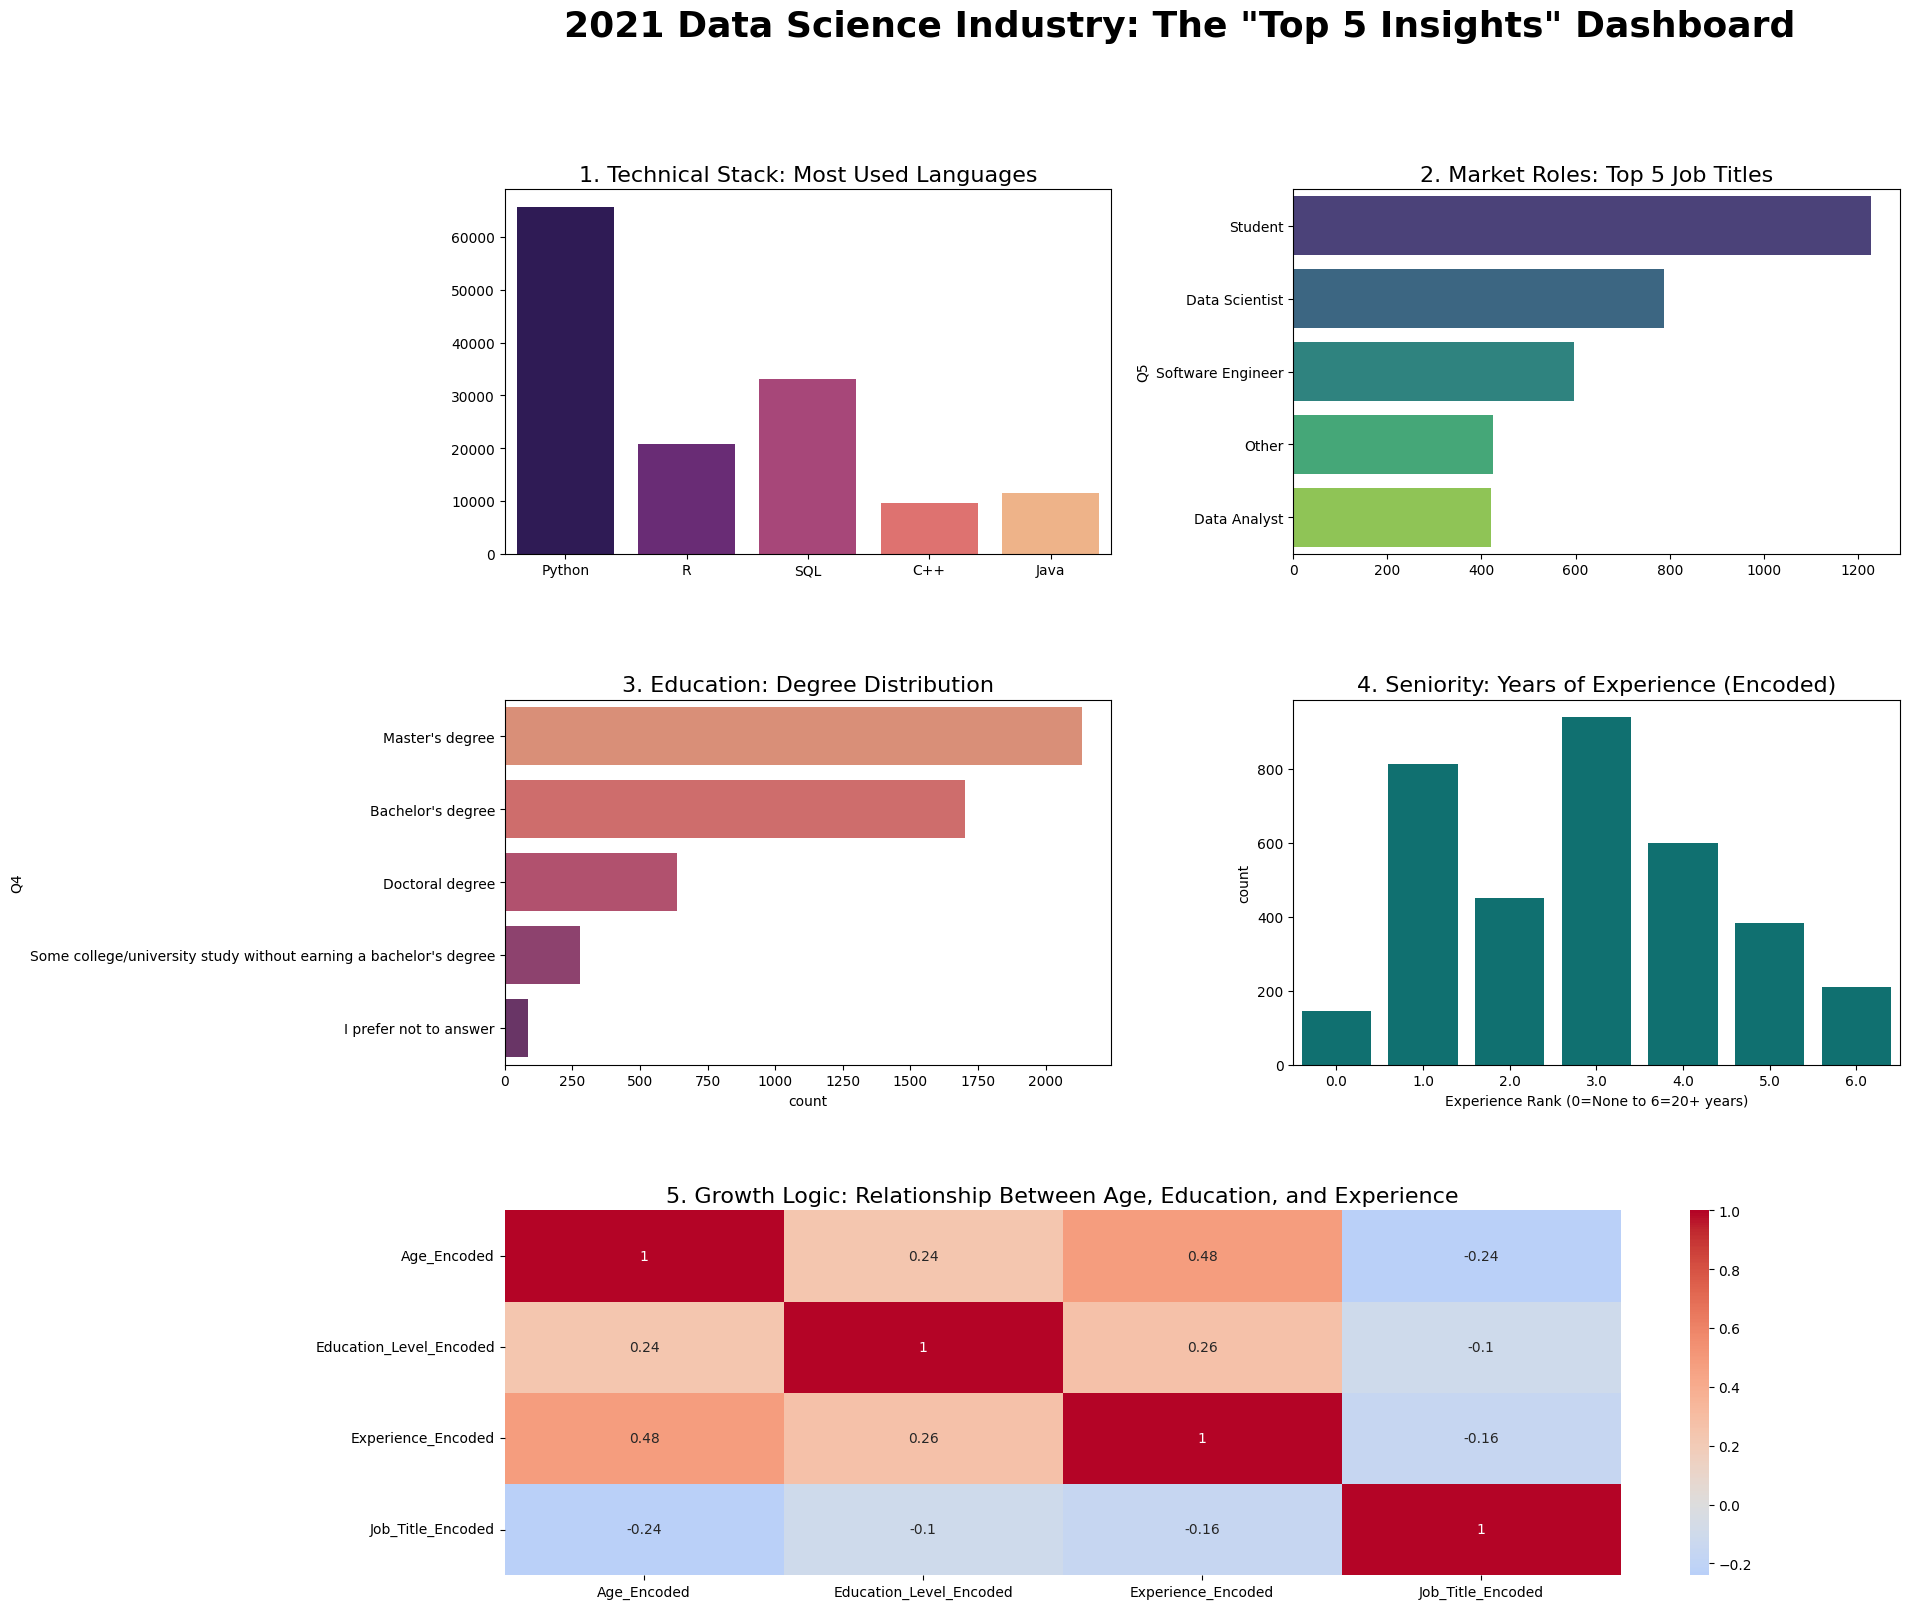

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Speed optimization: Use a sample for plotting
df_plot = df.sample(n=5000, random_state=42) if len(df) > 5000 else df

# 2. Setup the dashboard grid (3 rows, 2 columns)
fig = plt.figure(figsize=(18, 18))
plt.subplots_adjust(hspace=0.4, wspace=0.3)
fig.suptitle('2021 Data Science Industry: The "Top 5 Insights" Dashboard', fontsize=26, fontweight='bold')

# --- Insight 1: THE TOOLS (Programming Languages from Q7) ---
ax1 = plt.subplot(3, 2, 1)
top_langs = {
    'Python': df['Q7_Part_1_Binary'].sum(),
    'R': df['Q7_Part_2_Binary'].sum(),
    'SQL': df['Q7_Part_3_Binary'].sum(),
    'C++': df['Q7_Part_4_Binary'].sum(),
    'Java': df['Q7_Part_5_Binary'].sum()
}
sns.barplot(x=list(top_langs.keys()), y=list(top_langs.values()), ax=ax1, palette='magma')
ax1.set_title('1. Technical Stack: Most Used Languages', fontsize=16)

# --- Insight 2: THE ROLES (Professional Titles from Q5) ---
ax2 = plt.subplot(3, 2, 2)
top_jobs = df_plot['Q5'].value_counts().head(5)
sns.barplot(x=top_jobs.values, y=top_jobs.index, ax=ax2, palette='viridis')
ax2.set_title('2. Market Roles: Top 5 Job Titles', fontsize=16)

# --- Insight 3: THE PREPARATION (Education from Q4) ---
ax3 = plt.subplot(3, 2, 3)
edu_order = df_plot['Q4'].value_counts().head(5).index
sns.countplot(data=df_plot, y='Q4', order=edu_order, ax=ax3, palette='flare')
ax3.set_title('3. Education: Degree Distribution', fontsize=16)

# --- Insight 4: THE EXPERIENCE (Coding Years from Q6) ---
ax4 = plt.subplot(3, 2, 4)
sns.countplot(data=df_plot, x='Experience_Encoded', ax=ax4, color='teal')
ax4.set_title('4. Seniority: Years of Experience (Encoded)', fontsize=16)
ax4.set_xlabel('Experience Rank (0=None to 6=20+ years)')

# --- Insight 5: THE CONNECTION (Heatmap) ---
ax5 = plt.subplot(3, 1, 3) 
corr_cols = ['Age_Encoded', 'Education_Level_Encoded', 'Experience_Encoded', 'Job_Title_Encoded']
sns.heatmap(df_plot[corr_cols].corr(), annot=True, cmap='coolwarm', center=0, ax=ax5)
ax5.set_title('5. Growth Logic: Relationship Between Age, Education, and Experience', fontsize=16)

plt.show()